In [4]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

In [5]:
insurance_data = pd.read_csv("insurance.csv")

X = insurance_data.drop(columns="charges")
y = insurance_data["charges"]

X = pd.get_dummies(X, columns=["region"], drop_first = True, dtype=int)

X["sex"] = X["sex"].map({"female":1, "male":0})
X["smoker"] = X["smoker"].map({"yes":1, "no":0})

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

mean sq error for alpha = 0.001 :  20922599.871035963
mean sq error for alpha = 0.1 :  20921803.698431373
mean sq error for alpha = 0.2 :  20921006.729136664
mean sq error for alpha = 0.5 :  20918648.88982561
mean sq error for alpha = 0.75 :  20916722.237066403
mean sq error for alpha = 1 :  20914832.635089137
mean sq error for alpha = 2 :  20908106.779954523
mean sq error for alpha = 3 :  20901927.931570224
mean sq error for alpha = 5 :  20890881.000633497
mean sq error for alpha = 10 :  20872844.794796683
mean sq error for alpha = 20 :  20877828.53237883
mean sq error for alpha = 40 :  21046489.29389078
mean sq error for alpha = 80 :  21860927.299760204


<Axes: >

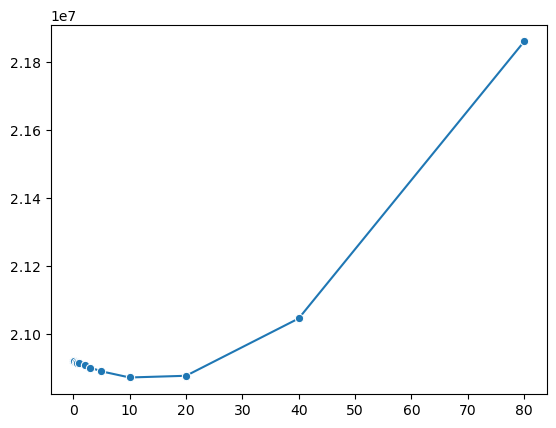

In [9]:
# implementing lasso model
# not preffered or beginner way of finding out right alpha value 

import seaborn as sns

alphas = [0.001, 0.1, 0.2, 0.5, 0.75, 1, 2, 3, 5, 10,20,40,80]
mse = []

for a in alphas:
    lasso_model = Lasso(alpha = a)
    lasso_model.fit(X_train, y_train)
    
    y_pred = lasso_model.predict(X_test)
    
    mean_sq_err = mean_squared_error(y_test,y_pred)
    print(f"mean sq error for alpha = {a} : ",mean_sq_err)
    mse.append(mean_sq_err)

sns.lineplot(x=alphas, y = mse, marker = 'o')

In [11]:
# practically using Lasso regression - LassoCV

from sklearn.linear_model import LassoCV
a = [0.001, 0.1, 0.2, 0.5, 0.75, 1, 2, 3, 5, 10,20,40,80]

lasso_cv_model = LassoCV(
    alphas = a,
    cv = 5,
    max_iter = 1000,
    random_state = 42
)

lasso_cv_model.fit(X_train, y_train)

print("best alpha value = ", lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("mean sq error : ", mse)

best alpha value =  0.001
mean sq error :  20922599.871035963


In [ ]:
## similarily ridge regression

In [ ]:
# elastic net